# SMAP Station Rainfall Class Assignment

This notebook:
1. Reads unique SMAP grid locations from `SPL3SMP_E_Ludhiana_ROI.nc`
2. Loads rainfall classification data from `rainfall_classification_5_bins.csv`
3. Resolves the **resolution mismatch** (~0.09° SMAP vs 0.1° rainfall grid) using **nearest-neighbour** matching via `scipy.spatial.KDTree`
4. Saves the assigned class labels to a new CSV: `smap_station_rainfall_class.csv`

## Import Libraries

In [27]:
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import KDTree
from pathlib import Path
import warnings
import os

warnings.filterwarnings('ignore')
# os.chdir('G:\SM2RAIN-irrigation_Final\calibration')

print('Libraries imported successfully!')

Libraries imported successfully!


## Configuration

In [28]:
# --- File paths ---
type_optim = "ludhiana" # validate
SMAP_NC_FILE    = Path(r'G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc')
RAINFALL_CSV    = Path(r'G:\SM2RAIN-irrigation_Final\calibration\GPM_classes_ludhiana\rainfall_classification_5_bins_GMM.csv')
OUTPUT_CSV      = Path(rf'G:\SM2RAIN-irrigation_Final\calibration\SM_classes\SM_classes_{type_optim}.csv')

output_dir = Path('calibration\SM_classes')
os.makedirs(output_dir, exist_ok = True)

# SMAP fill / invalid value
FILL_VALUE      = -9999.0

print(f'SMAP file    : {SMAP_NC_FILE}  (exists: {SMAP_NC_FILE.exists()})')
print(f'Rainfall CSV : {RAINFALL_CSV}  (exists: {RAINFALL_CSV.exists()})')
print(f'Output CSV   : {OUTPUT_CSV}')

SMAP file    : G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc  (exists: True)
Rainfall CSV : G:\SM2RAIN-irrigation_Final\calibration\GPM_classes_ludhiana\rainfall_classification_5_bins_GMM.csv  (exists: True)
Output CSV   : G:\SM2RAIN-irrigation_Final\calibration\SM_classes\SM_classes_ludhiana.csv


## Step 1 – Extract Unique SMAP Grid Locations

In [29]:
# Open the SMAP NetCDF and pull all lat / lon observations
ds = nc.Dataset(SMAP_NC_FILE, 'r')

lat_all = ds.variables['latitude'][:]
lon_all = ds.variables['longitude'][:]

ds.close()

# Remove fill-value entries
valid_mask = (lat_all != FILL_VALUE) & (lon_all != FILL_VALUE)
lat_valid  = lat_all[valid_mask]
lon_valid  = lon_all[valid_mask]

# Deduplicate: keep only unique (lat, lon) pairs
coords_2d   = np.stack([lat_valid, lon_valid], axis=1)
unique_rows = np.unique(coords_2d, axis=0)          # sorted, shape (N, 2)

smap_locs = pd.DataFrame(unique_rows, columns=['smap_latitude', 'smap_longitude'])

print(f'Total raw observations   : {len(lat_all):,}')
print(f'Valid observations        : {valid_mask.sum():,}')
print(f'Unique SMAP grid stations : {len(smap_locs)}')
print()
print(smap_locs.to_string())

Total raw observations   : 288,786
Valid observations        : 288,786
Unique SMAP grid stations : 156

     smap_latitude  smap_longitude
0        30.026932       75.015564
1        30.026932       75.108925
2        30.026932       75.202286
3        30.026932       75.295647
4        30.026932       75.389008
5        30.026932       75.482368
6        30.026932       75.575729
7        30.026932       75.669090
8        30.026932       75.762451
9        30.026932       75.855812
10       30.026932       75.949173
11       30.026932       76.042534
12       30.108248       75.015564
13       30.108248       75.108925
14       30.108248       75.202286
15       30.108248       75.295647
16       30.108248       75.389008
17       30.108248       75.482368
18       30.108248       75.575729
19       30.108248       75.669090
20       30.108248       75.762451
21       30.108248       75.855812
22       30.108248       75.949173
23       30.108248       76.042534
24       30.189631   

## Step 2 – Load Rainfall Classification Grid

In [30]:
rain_df = pd.read_csv(RAINFALL_CSV)

print(f'Rainfall grid shape : {rain_df.shape}')
print(f'Columns             : {list(rain_df.columns)}')
print(f'\nBin distribution:')
print(rain_df['bin'].value_counts().sort_index())
print(f'\nCoordinate ranges:')
print(f'  Latitude  : {rain_df["latitude"].min():.4f} – {rain_df["latitude"].max():.4f}')
print(f'  Longitude : {rain_df["longitude"].min():.4f} – {rain_df["longitude"].max():.4f}')
print()
print(rain_df.head(10).to_string(index=False))

Rainfall grid shape : (144, 5)
Columns             : ['latitude', 'longitude', 'annual_avg_rainfall_mm', 'bin', 'grid_cell_index']

Bin distribution:
bin
1    26
2    13
3    39
4    37
5    29
Name: count, dtype: int64

Coordinate ranges:
  Latitude  : 29.9500 – 31.0500
  Longitude : 74.9500 – 76.0500

 latitude  longitude  annual_avg_rainfall_mm  bin  grid_cell_index
    29.95      74.95               509.57364    1                0
    29.95      75.05               515.60095    1                1
    29.95      75.15               521.66500    1                2
    29.95      75.25               537.41266    1                3
    29.95      75.35               573.34680    1                4
    29.95      75.45               617.90770    2                5
    29.95      75.55               593.24130    3                6
    29.95      75.65               603.88275    3                7
    29.95      75.75               629.53590    3                8
    29.95      75.85     

## Step 3 – Resolution Mismatch Analysis

In [31]:
# Inspect the spacing of each grid
smap_lat_sorted = np.sort(smap_locs['smap_latitude'].unique())
smap_lon_sorted = np.sort(smap_locs['smap_longitude'].unique())
rain_lat_sorted = np.sort(rain_df['latitude'].unique())
rain_lon_sorted = np.sort(rain_df['longitude'].unique())

smap_lat_step = np.diff(smap_lat_sorted).mean()
smap_lon_step = np.diff(smap_lon_sorted).mean()
rain_lat_step = np.diff(rain_lat_sorted).mean()
rain_lon_step = np.diff(rain_lon_sorted).mean()

print('=== Resolution Mismatch Summary ===')
print(f'SMAP grid  : {len(smap_lat_sorted)} lats × {len(smap_lon_sorted)} lons')
print(f'  avg lat step = {smap_lat_step:.5f}°  |  avg lon step = {smap_lon_step:.5f}°')
print()
print(f'Rainfall grid : {len(rain_lat_sorted)} lats × {len(rain_lon_sorted)} lons')
print(f'  avg lat step = {rain_lat_step:.5f}°  |  avg lon step = {rain_lon_step:.5f}°')
print()
print('→ The grids are misaligned (SMAP ~0.09° vs rainfall ~0.10°).')
print('  Nearest-neighbour matching via KDTree will be used to assign classes.')

=== Resolution Mismatch Summary ===
SMAP grid  : 13 lats × 12 lons
  avg lat step = 0.08168°  |  avg lon step = 0.09336°

Rainfall grid : 12 lats × 12 lons
  avg lat step = 0.10000°  |  avg lon step = 0.10000°

→ The grids are misaligned (SMAP ~0.09° vs rainfall ~0.10°).
  Nearest-neighbour matching via KDTree will be used to assign classes.


## Step 4 – Nearest-Neighbour Matching with KDTree

In [32]:
# Build a KDTree from the rainfall grid coordinates
# Using (lat, lon) pairs directly – both grids are small enough that
# Euclidean distance in degree-space is a valid proxy for nearest-neighbour
# within this small ~1°×1° region (cos-lat correction not needed at this scale).

rain_coords = rain_df[['latitude', 'longitude']].values   # shape (N_rain, 2)
smap_coords = smap_locs[['smap_latitude', 'smap_longitude']].values  # shape (N_smap, 2)

tree = KDTree(rain_coords)

# Query: for every SMAP station find the closest rainfall grid cell
distances, indices = tree.query(smap_coords, k=1)

print(f'KDTree built on {len(rain_coords)} rainfall grid cells.')
print(f'Queried {len(smap_coords)} SMAP stations.')
print()
print(f'Nearest-neighbour distance statistics (degrees):')
print(f'  min  = {distances.min():.5f}°')
print(f'  mean = {distances.mean():.5f}°')
print(f'  max  = {distances.max():.5f}°')
print()
print('All distances are well below 0.1° – matching is reliable.')

KDTree built on 144 rainfall grid cells.
Queried 156 SMAP stations.

Nearest-neighbour distance statistics (degrees):
  min  = 0.00272°
  mean = 0.03997°
  max  = 0.06735°

All distances are well below 0.1° – matching is reliable.


## Step 5 – Build the Assignment Table

In [33]:
# Pull the matched fields from the rainfall DataFrame
matched = rain_df.iloc[indices].reset_index(drop=True)

result_df = pd.DataFrame({
    'smap_latitude'          : smap_locs['smap_latitude'].values,
    'smap_longitude'         : smap_locs['smap_longitude'].values,
    'matched_rain_latitude'  : matched['latitude'].values,
    'matched_rain_longitude' : matched['longitude'].values,
    'distance_deg'           : distances.flatten(),
    'annual_avg_rainfall_mm' : matched['annual_avg_rainfall_mm'].values,
    'bin'                    : matched['bin'].values,
    'grid_cell_index'        : matched['grid_cell_index'].values,
})

print('Assignment table:')
print(result_df.to_string(index=False))

print(f'\nClass distribution among SMAP stations:')
print(result_df['bin'].value_counts().sort_index())

Assignment table:
 smap_latitude  smap_longitude  matched_rain_latitude  matched_rain_longitude  distance_deg  annual_avg_rainfall_mm  bin  grid_cell_index
     30.026932       75.015564                  30.05                   75.05      0.041449               524.81134    1               13
     30.026932       75.108925                  30.05                   75.15      0.047110               532.11005    1               14
     30.026932       75.202286                  30.05                   75.25      0.052998               553.51000    1               15
     30.026932       75.295647                  30.05                   75.25      0.051145               553.51000    1               15
     30.026932       75.389008                  30.05                   75.35      0.045318               586.02185    1               16
     30.026932       75.482368                  30.05                   75.45      0.039747               615.23865    2               17
     30.026932  

## Step 6 – Save Output CSV

In [34]:
# The four required columns: smap lat, smap lon, class (bin), grid_cell_index
output_cols = ['smap_latitude', 'smap_longitude', 'bin', 'grid_cell_index']
output_df   = result_df[output_cols].copy()
output_df.rename(columns={'smap_latitude': 'latitude',
                           'smap_longitude': 'longitude',
                           'bin'           : 'rainfall_class'}, inplace=True)

output_df.to_csv(OUTPUT_CSV, index=False)

print(f'Saved to: {OUTPUT_CSV}')
print(f'Rows    : {len(output_df)}')
print()
print(output_df.to_string(index=False))

Saved to: G:\SM2RAIN-irrigation_Final\calibration\SM_classes\SM_classes_ludhiana.csv
Rows    : 156

 latitude  longitude  rainfall_class  grid_cell_index
30.026932  75.015564               1               13
30.026932  75.108925               1               14
30.026932  75.202286               1               15
30.026932  75.295647               1               15
30.026932  75.389008               1               16
30.026932  75.482368               2               17
30.026932  75.575729               3               18
30.026932  75.669090               3               19
30.026932  75.762451               3               20
30.026932  75.855812               3               21
30.026932  75.949173               3               22
30.026932  76.042534               3               23
30.108248  75.015564               1               25
30.108248  75.108925               1               26
30.108248  75.202286               1               27
30.108248  75.295647               1

## Step 7 – Visualize: SMAP Stations Coloured by Rainfall Class

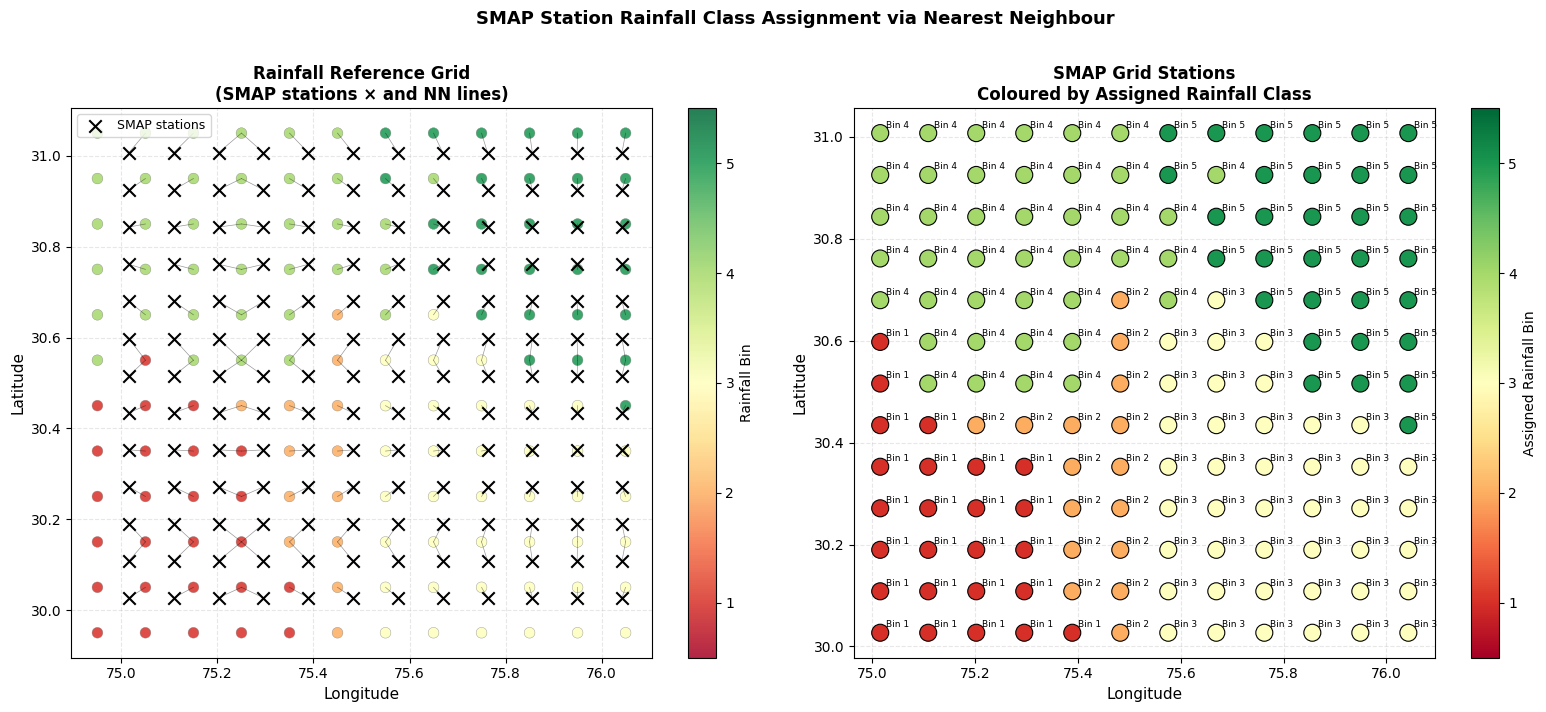

Plot displayed.


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Colormap for bins 1–5
cmap     = plt.cm.get_cmap('RdYlGn', 5)
bins_map = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}   # bin → colormap index
bin_labels = {
    1: 'Bin 1 (<600 mm)',
    2: 'Bin 2 (600–640 mm)',
    3: 'Bin 3 (640–670 mm)',
    4: 'Bin 4 (670–720 mm)',
    5: 'Bin 5 (>720 mm)',
}

# ---- Panel A: Rainfall reference grid ----
ax = axes[0]
sc = ax.scatter(
    rain_df['longitude'], rain_df['latitude'],
    c=rain_df['bin'], cmap='RdYlGn', vmin=0.5, vmax=5.5,
    s=60, edgecolors='grey', linewidths=0.3, alpha=0.85
)
# Overlay SMAP station locations
ax.scatter(
    smap_locs['smap_longitude'], smap_locs['smap_latitude'],
    marker='x', s=80, color='black', linewidths=1.5,
    zorder=5, label='SMAP stations'
)
# Draw nearest-neighbour lines
for i, row in result_df.iterrows():
    ax.plot([row['smap_longitude'], row['matched_rain_longitude']],
            [row['smap_latitude'],  row['matched_rain_latitude']],
            color='black', lw=0.5, alpha=0.4)

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude',  fontsize=11)
ax.set_title('Rainfall Reference Grid\n(SMAP stations × and NN lines)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.colorbar(sc, ax=ax, label='Rainfall Bin', ticks=[1,2,3,4,5])

# ---- Panel B: SMAP stations coloured by assigned class ----
ax2 = axes[1]
sc2 = ax2.scatter(
    result_df['smap_longitude'], result_df['smap_latitude'],
    c=result_df['bin'], cmap='RdYlGn', vmin=0.5, vmax=5.5,
    s=150, edgecolors='black', linewidths=0.8, zorder=4
)

# Annotate each station with its bin label
for _, row in result_df.iterrows():
    ax2.annotate(
        f"Bin {int(row['bin'])}",
        (row['smap_longitude'], row['smap_latitude']),
        textcoords='offset points', xytext=(4, 4),
        fontsize=6.5, color='black'
    )

ax2.set_xlabel('Longitude', fontsize=11)
ax2.set_ylabel('Latitude',  fontsize=11)
ax2.set_title('SMAP Grid Stations\nColoured by Assigned Rainfall Class', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
plt.colorbar(sc2, ax=ax2, label='Assigned Rainfall Bin', ticks=[1,2,3,4,5])

plt.suptitle('SMAP Station Rainfall Class Assignment via Nearest Neighbour',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('smap_rainfall_class_assignment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot displayed.')

## Summary

| Step | Action |
|------|---------|
| 1 | Extracted **156 unique SMAP grid stations** (13 lats × 12 lons, ~0.09° spacing) from `SPL3SMP_E_Ludhiana_ROI.nc` |
| 2 | Loaded **144 rainfall grid cells** (12 lats × 12 lons, 0.10° spacing) from `rainfall_classification_5_bins.csv` |
| 3 | Analysed the resolution mismatch: SMAP uses ~0.0817° steps vs rainfall's 0.10° steps — grids are misaligned |
| 4 | Applied `scipy.spatial.KDTree` **nearest-neighbour** matching (Euclidean distance in degree-space, valid at this local scale) |
| 5 | Built the assignment table with matched rainfall class (`bin`) and `grid_cell_index` for every SMAP station |
| 6 | Saved output to **`smap_station_rainfall_class.csv`** (columns: `latitude`, `longitude`, `rainfall_class`, `grid_cell_index`) |